In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

导入要用的py库，这里的机器学习算法用python3.13.13实现
尝试使用梯度下降法做这个作业

In [27]:
class LinearRegression(object):
    #定义线性回归算法大类，第一次不引入正则化惩罚
    def __init__ (self):
        #初始化各个参数
        self.w = 0 #斜率
        self.b = 0 #截距
        self.sqrLoss = 0 #最小均方误差
        self.Xset = 0 #x轴对应的存储变量，也称特征
        self.Yset = 0 #y轴对应存储变量，也称标签
        #x和y都是训练集的，线性回归算法是一种监督学习算法，必须要训练集数据
        self.Lrate = None #学习率，梯度下降算法会用到
        self.n_iters = None #最大迭代次数
        self.lossList = [] #每轮迭代产生的误差列表

    def train(self,Xt,Yt,Lrate = 0.01,n_iters = 1000):
        if Xt.ndim < 2:
            raise ValueError("X至少是一个二维的数组！")
        self.Xset = Xt
        self.Yset = Yt #将输入量传入类中
        X = self.Xset
        Y = self.Yset
        minLoss = 1.0e-6
        ns,nf=self.Xset.shape #用ns储存x行数，用nf储存x列数
        n=0 #迭代次数计数器
        w = np.ones(nf) #生成X列数相同的w权重矩阵，这样能与X相乘，同时让每个值为1方便之后的赋值
        b = 1
        sqrLoss0 = np.power((Y-np.dot(X,w)).flatten()-b,2).mean()#计算当前的残差平方和
        self.lossList.append(sqrLoss0)
        deltaLoss = np.inf #用于储存两次迭代之间的差值，如果这个差值比我们给出的最小损失都小了，那可以近似认为拟合完成，先用inf初始化，让第一次循环一定会发生
        while (n < n_iters) and (sqrLoss0>minLoss) and (abs(deltaLoss) > minLoss):
            #求w和b的梯度
            ypre = np.dot(X,w)+b #y的预测值，用于写出残差方程
            error = Y-ypre
            #向后传播
            gradw = (-2/ns)*np.dot(X.T,error)
            gradb = (-2/ns)*np.sum(error)
            #参数更新
            w -= Lrate*gradw
            b -= Lrate*gradb
            #损失更新
            newsqrLoss = np.mean((Y-np.dot(X,w)-b)**2)
            deltaLoss = sqrLoss0-newsqrLoss
            sqrLoss = newsqrLoss
            self.lossList.append(sqrLoss)
            n+=1
        self.w = w
        self.b = b
        print("第{}次迭代，损失平方和为{}，损失前后差为{}".format(n,sqrLoss,deltaLoss))

    def predict(self, X):
        return np.dot(X, self.w) + self.b

主体训练函数写好了，下面是对数据进行处理，首要的就是标准化，然后是调用函数

In [28]:
#加载数据集
housing = fetch_california_housing()
X = housing.data
Y = housing.target
#标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()


model.train(
    Xt = X_scaled,
    Yt = Y,
    Lrate = 0.1,
    n_iters = 1000
)

(20640, 8)
第1000次迭代，损失平方和为0.5243209878315738，损失前后差为7.353774617137791


绘图绘图！

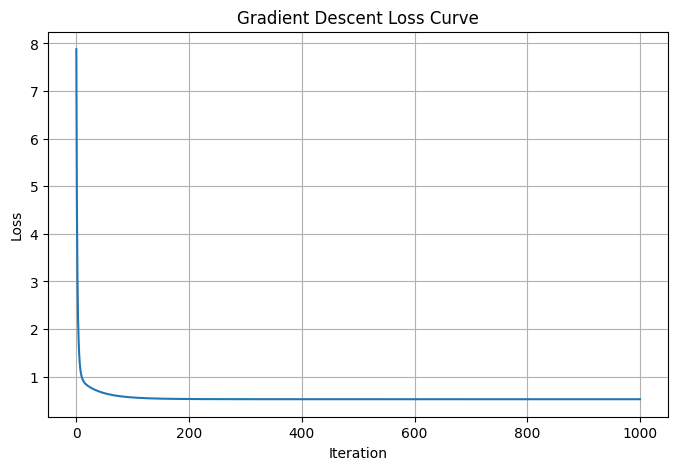

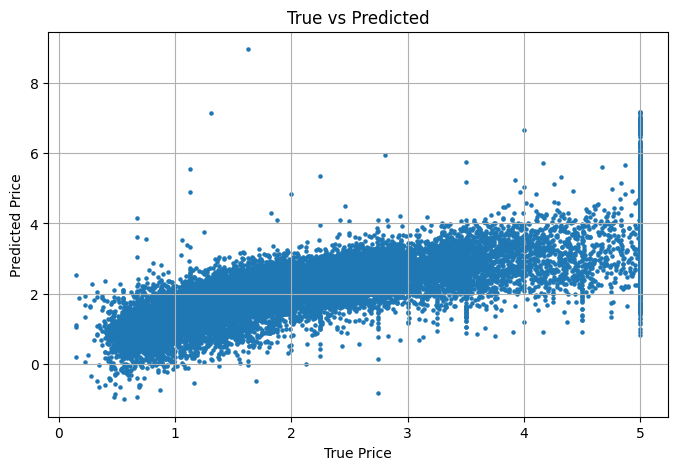

[ 0.82966533  0.11876019 -0.26561401  0.30576836 -0.00450049 -0.03932797
 -0.89978021 -0.87044092]


In [30]:
y_pred = model.predict(X_scaled)
plt.figure(figsize=(8,5))
plt.plot(model.lossList)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient Descent Loss Curve")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(Y, y_pred, s=5)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("True vs Predicted")
plt.grid(True)
plt.show()